<a href="https://colab.research.google.com/github/ayan42not/quantum-programing/blob/main/quantum-with-qiskit/Q50_Mathematical_Simulation_of_Quantum_Circuits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://qworld.net" target="_blank" align="left"><img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/qworld/images/header.jpg?raw=1"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

<font style="font-size:28px;" align="left"><b> Mathematical Simulation of Quantum Circuits </b></font>
<br>
_prepared by Saba Bozpolat_
<br><br>

In [3]:
!pip install -q qiskit[all] qiskit_aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 26.2 MB/s eta 0:00:00


We have been designing quantum circuits in Qiskit and reading their statevectors.

In this notebook, we take a step back and ask: what is Qiskit actually computing under the hood?

The answer is matrix-vector multiplication — the same linear algebra we have already been using on the unit circle.

<hr>

<h3>From circuit to matrix expression</h3>

In Qiskit, the default initial state of every qubit is $ \ket{0} $.

Each gate is a matrix. Applying a gate to a state means multiplying the state vector by that matrix.

Let us start with the simplest case: a single gate applied to $ \ket{0} $.

<b>Example 1: X gate</b>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_x.png?raw=1" height="20%" align="center">
</pre>

The qubit starts in $ \ket{0} $ and a single X gate is applied. The mathematical expression is:

$$ X \ket{0} $$

Computing the result:

$$
X \ket{0} = \X \vzero = \vone = \ket{1}
$$

X flips the state, as expected.

Z kapısının qubit üzerindeki etkileri çok nettir:
Qubit \(\vert{}0\rangle\) durumundaysa: Hiçbir şey yapmaz. Qubit aynen kalır.Qubit \(\vert{}1\rangle\) durumundaysa: Önüne eksi (-) işareti koyar.
Durum \(-\vert{}1\rangle\) olur.

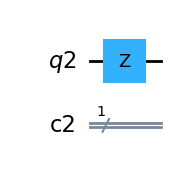

amplitude of |0>: 1.0
amplitude of |1>: -0.0


In [8]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

qc.z(q[0])
display(qc.draw("mpl"))

job = StatevectorSimulator().run(qc, optimization_level=0)
state = job.result().get_statevector(qc).data

print("amplitude of |0>:", round(state[0].real, 4))
print("amplitude of |1>:", round(state[1].real, 4))

<b>Example 2: H gate</b>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_h.png?raw=1" height="20%" align="center">
</pre>

The qubit starts in $ \ket{0} $ and a single H gate is applied. The mathematical expression is:

$$ H \ket{0} $$

Computing the result:

$$
H \ket{0} = \hadamard \vzero = \myvector{ \sqrttwo \\ \sqrttwo } = \ket{+}
$$

H creates an equal superposition.

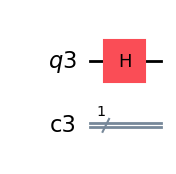

amplitude of |0>: 0.7071
amplitude of |1>: 0.7071


In [9]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

qc.h(q[0])
display(qc.draw("mpl"))

job = StatevectorSimulator().run(qc, optimization_level=0)
state = job.result().get_statevector(qc).data

print("amplitude of |0>:", round(state[0].real, 4))
print("amplitude of |1>:", round(state[1].real, 4))

<h3> Task 1 </h3>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_z.png?raw=1" height="20%" align="center">
</pre>

For the circuit, write the mathematical expression, compute the result by hand, and verify with Qiskit.

<i>Recall: $ Z = \Z $</i>

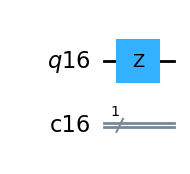

amplutude of |0> is  1.0
amplutude of |1> is  -0.0


In [22]:
#
# your solution is here
#
from qiskit import ClassicalRegister,QuantumRegister,QuantumCircuit
from qiskit_aer import StatevectorSimulator
q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)
qc.z([0])

display(qc.draw(output="mpl"))

job=StatevectorSimulator().run(qc)
state=job.result().get_statevector(qc).data

print("amplutude of |0> is ",round(state[0].real,4))
print("amplutude of |1> is ",round(state[1].real,4))

<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task1">click for our solution</a>

<hr>
<h3>Multi-gate circuits</h3>

When a circuit contains more than one gate, the gates are applied left to right in the circuit diagram.

In the mathematical expression, the gate applied <i>first</i> appears <i>rightmost</i>. This follows from how matrix multiplication works — it acts on vectors from the right, exactly like function composition:

$$ (B \circ A)(\ket{v}) = B\big(A(\ket{v})\big) \quad \longleftrightarrow \quad B A \ket{v} $$

So a circuit that applies gate $A$ first, then gate $B$, corresponds to the expression $ B A \ket{v} $.

<b>Example: H then Z applied to $ \ket{0} $</b>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_HZ.png?raw=1" height="20%" align="center">
</pre>


H is applied first (leftmost), then Z. The mathematical expression is:

$$ Z H \ket{0} $$

**Step 1:** Apply H to $ \ket{0} $:

$$
H \ket{0} = \hadamard \vzero = \myvector{ \sqrttwo \\ \sqrttwo } = \ket{+}
$$

**Step 2:** Apply Z to $ \ket{+} $:

$$
Z \ket{+} = \Z \myvector{ \sqrttwo \\ \sqrttwo } = \myvector{ \sqrttwo \\ -\sqrttwo } = \ket{-}
$$

Z flips the sign of the $ \ket{1} $ amplitude, turning $ \ket{+} $ into $ \ket{-} $.

amplitude of |0>: 0.7071
amplitude of |1>: -0.7071


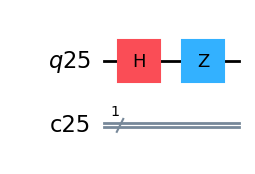

In [31]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

qc.h(q[0])  # apply H first
qc.z(q[0])  # apply Z second


job = StatevectorSimulator().run(qc, optimization_level=0)
state = job.result().get_statevector(qc).data

print("amplitude of |0>:", round(state[0].real, 4))
print("amplitude of |1>:", round(state[1].real, 4))
qc.draw(output="mpl")

<h3>The combined operator</h3>

Instead of applying gates one by one, we can first multiply the matrices into a single combined operator, then apply it to the initial state.

For the example above:

$$
ZH = \Z \hadamard = \mymatrix{rr}{ \sqrttwo & -\sqrttwo \\ -\sqrttwo & \sqrttwo }
$$

Applying this to $ \ket{0} $:

$$
(ZH) \ket{0} = \mymatrix{rr}{ \sqrttwo & -\sqrttwo \\ -\sqrttwo & \sqrttwo } \vzero = \myvector{ \sqrttwo \\ -\sqrttwo } = \ket{-}
$$

Same result, as expected. Notice that $ZH$ is a reflection matrix — the circuit H then Z is equivalent to a single reflection.

<h3> Task 2 </h3>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_RyZ.png?raw=1" height="20%" align="center">
</pre>

<b>(a)</b> Write the mathematical expression for the final state.

$\ket{\phi_{final}}$=Z⋅$R_y$⋅$\ket{0}$

<b>(b)</b> Compute the final state step by step: first apply $ R_y(\pi/4) $, then apply Z to the result.

$$ R_y(\pi/4)|0\rangle = \begin{pmatrix} \cos(\pi/8) & -\sin(\pi/8) \\ \sin(\pi/8) & \cos(\pi/8) \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} \cos(\pi/8) \\ \sin(\pi/8) \end{pmatrix} $$


$$ Z \cdot \begin{pmatrix} \cos(\pi/8) \\ \sin(\pi/8) \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix} \begin{pmatrix} \cos(\pi/8) \\ \sin(\pi/8) \end{pmatrix} = \begin{pmatrix} \cos(\pi/8) \\ -\sin(\pi/8) \end{pmatrix} $$


<b>(c)</b> Verify with Qiskit.

<i>Recall: $ R_y(\theta) = \mymatrix{rr}{ \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) } $ and in Qiskit: <code>qc.ry(angle, q[0])</code></i>

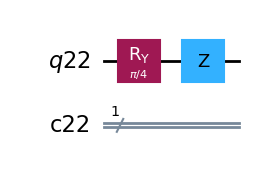

In [28]:
#
# your solution is here
#

from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator
from math import pi
q = QuantumRegister(1)
c = ClassicalRegister(1)
qc = QuantumCircuit(q, c)

theta=pi/8
qc.ry(2*theta,q)
qc.z(q)
qc.draw(output="mpl")


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task2">click for our solution</a>

<h3> Task 4 </h3>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_HXZ.png?raw=1" height="20%" align="center"><!--&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_ZXH.png?raw=1" height="20%" align="center">-->
</pre>

Before running the code below, predict the final state by computing $ Z X H \ket{0} $ by hand.

Then run the code and check whether your prediction is correct.

In [32]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)

# after H
qc1 = QuantumCircuit(q, c)
qc1.h(q[0])
state1 = StatevectorSimulator().run(qc1, optimization_level=0).result().get_statevector(qc1).data
print("After H:    ", [round(a.real, 4) for a in state1])

# after H, X
qc2 = QuantumCircuit(q, c)
qc2.h(q[0])
qc2.x(q[0])
state2 = StatevectorSimulator().run(qc2, optimization_level=0).result().get_statevector(qc2).data
print("After H,X:  ", [round(a.real, 4) for a in state2])

# after H, X, Z
qc3 = QuantumCircuit(q, c)
qc3.h(q[0])
qc3.x(q[0])
qc3.z(q[0])
state3 = StatevectorSimulator().run(qc3, optimization_level=0).result().get_statevector(qc3).data
print("After H,X,Z:", [round(a.real, 4) for a in state3])

After H:     [np.float64(0.7071), np.float64(0.7071)]
After H,X:   [np.float64(0.7071), np.float64(0.7071)]
After H,X,Z: [np.float64(0.7071), np.float64(-0.7071)]


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task3">click for our solution</a>

<hr>
<h3>The order of gates matters</h3>

In general, matrix multiplication is not commutative: $ AB \neq BA $.

This means the order of gates in a circuit is significant. Swapping two gates will, in general, produce a different final state.

Task 3 above demonstrated this directly: $ HX\ket{0} = \ket{-} $ while $ XH\ket{0} = \ket{+} $.

There are special cases where two gates do commute — for example $ XX = I $, $ ZZ = I $ — but these are exceptions, not the rule.

<h3> Task 3 </h3>

Consider the following two circuits:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_XH.png?raw=1" height="20%" align="center">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_HX.png?raw=1" height="20%" align="center">
</pre>

<b>(a)</b> Write the mathematical expression for the final state of each circuit.


*   $\ket{\phi_{final1}}$=XH$\ket{0}$
*   $\ket{\phi_{final1}}$=HX$\ket{0}$



<b>(b)</b> Compute both results by hand.

<b>(c)</b> Verify both with Qiskit.

<b>(d)</b> Are the results the same? What does this tell you about the order of gates?

In [42]:
#
# your solution is here
#
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import StatevectorSimulator

q = QuantumRegister(1)
c = ClassicalRegister(1)

# after H
qc1 = QuantumCircuit(q, c)
qc1.x(q[0])
qc1.h(q[0])
job=StatevectorSimulator().run(qc1)
state=job.result().get_statevector(qc1).data

print(f"A of ket0:",round(state.real[0],4))
print(f"A of ket1:",round(state.real[1],4))


# after H
qc2 = QuantumCircuit(q, c)
qc2.h(q[0])
qc2.x(q[0])
job=StatevectorSimulator().run(qc2)
state=job.result().get_statevector(qc2).data

print(f"A of ket0:",round(state.real[0],4))
print(f"A of ket1:",round(state.real[1],4))



A of ket0: 0.7071
A of ket1: -0.7071
A of ket0: 0.7071
A of ket1: 0.7071


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task4">click for our solution</a>

<hr>
<h3>Unitary matrices and reversibility</h3>

Every quantum gate matrix $U$ satisfies the property:

$$ U^T U = I $$

where $U^T$ is the transpose of $U$ (we are working with real-valued gates throughout this tutorial, so the transpose suffices here).

Such a matrix is called <b>orthogonal</b> (or more generally, <b>unitary</b>). It preserves the length of any state vector:

$$ \norm{ U \ket{v} } = \norm{ \ket{v} } $$

This is not a coincidence — it is a requirement. A quantum state must always remain a unit vector (the sum of squared amplitudes must equal 1), so every valid quantum gate must be unitary.

A useful consequence: since $ U^T U = I $, we have $ U^{-1} = U^T $. Every gate is invertible, and its inverse is simply its transpose. Quantum computation is inherently reversible.

For H, X, and Z:

$$ H^{-1} = H^T = H \qquad X^{-1} = X^T = X \qquad Z^{-1} = Z^T = Z $$

All three gates are their own inverses.

<h3> Task 5 </h3>

Verify by hand that $ H^T H = I $.

Then consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_XHH.png?raw=1" height="20%" align="center">
</pre>

The first X prepares the state $ \ket{1} $, then H is applied twice. Predict the final state and verify with Qiskit.

amplitude of 0:0.0
amplitude of 1:1.0


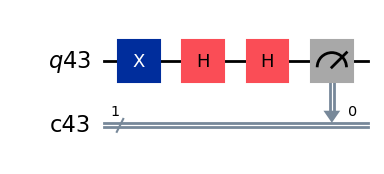

In [51]:
#
# your solution is here
#

from qiskit import QuantumRegister,ClassicalRegister,QuantumCircuit

q=QuantumRegister(1)
c=ClassicalRegister(1)
qc=QuantumCircuit(q,c)
qc.x(q)
qc.h(q)
qc.h(q)

qc.measure(q,c)
job=StatevectorSimulator().run(qc)
state=job.result().get_statevector(qc).data

amp_0=round(state[0].real,4)
amp_1=round(state[1].real,4)
print(f"amplitude of 0:{amp_0}")
print(f"amplitude of 1:{amp_1}")
qc.draw(output="mpl")

<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task5">click for our solution</a>

<hr>
<h3>Inverting a circuit</h3>

Since every gate is its own inverse (for H, X, Z), we can undo a sequence of gates by applying them in reverse order.

If the circuit applies gates $ A $, then $ B $, then $ C $, the combined operator is $ C B A $.

To invert this:

$$ (CBA)^{-1} = A^{-1} B^{-1} C^{-1} $$

For H, X, Z where each gate equals its own inverse, this becomes:

$$ (CBA)^{-1} = A B C $$

So to undo the circuit, apply the same gates in reverse order.

For example, consider the original circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_HXZH.png?raw=1" height="20%" align="center">
</pre>

Its inverse is obtained by applying the same gates in reverse order:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_HZXH.png?raw=1" height="20%" align="center">
</pre>

Appending the inverse circuit to the original returns the qubit to its initial state $ \ket{0} $.

<h3> Task 6 </h3>

Implement the original circuit and its inverse in Qiskit and verify that the final state is $ \ket{0} $.

In [ ]:
#
# your solution is here
#


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task6">click for our solution</a>

<hr>
<h3>Gates and rotations</h3>

We have already seen that every quantum gate on a single real-valued qubit acts as either a rotation or a reflection on the unit circle.

- $ H $, $ X $, $ Z $ are reflections.
- $ R_y(\theta) $ is a rotation.

A product of two reflections is a rotation. A product of two rotations is also a rotation. A product of a reflection and a rotation is a reflection.

This geometric perspective can help us predict the type of the combined operator before doing any matrix multiplication.

<h3> Task 7 (Extra) </h3>

Consider the following circuit:

<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_RyHRy.png?raw=1" height="20%" align="center">
</pre>

<b>(a)</b> Write the mathematical expression for the final state.
$\ket{Φ_{final}}$=R_y($\pi/3$)HR_y($\pi/6$)$\ket{0}$

<b>(b)</b> Compute the final state by applying the gates one by one.

<b>(c)</b> Verify with Qiskit by reading the final statevector and drawing the state on the unit circle.

--2026-06-13 17:02:38--  https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/quantum-with-qiskit/quantum.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 383 [text/plain]
Saving to: ‘quantum.py’

quantum.py          100%[===================>]     383  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-06-13 17:02:38 (21.9 MB/s) - ‘quantum.py’ saved [383/383]

--2026-06-13 17:02:38--  https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/drawing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connecte

<Figure size 640x480 with 0 Axes>

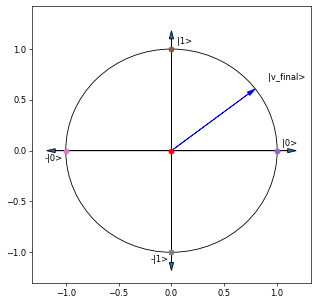

In [55]:
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/quantum-with-qiskit/quantum.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/drawing.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/quantum_state.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/grover.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/quantum_operator.py
# include our predefined functions
%run quantum.py

#
# your solution is here
#

draw_qubit()
from qiskit import QuantumRegister,ClassicalRegister,QuantumCircuit
from math import pi
q=QuantumRegister(1)
c=ClassicalRegister(1)
qc=QuantumCircuit(q,c)

angle1=pi/6
angle2=pi/8

qc.ry(2*angle1,q)
qc.h(q)
qc.ry(2*angle2,q)
job=StatevectorSimulator().run(qc)
state=job.result().get_statevector(qc).data
draw_quantum_state(state[0].real,state[1].real,"|v_final>")


<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task7">click for our solution</a>

<h3> Task 8 (Extra) </h3>

Consider the circuit from Task 7
<!--
<pre>
&nbsp;&nbsp;&nbsp;<img src="https://github.com/sbbzplt/QWorld-Bronze/blob/master/quantum-with-qiskit/images/circuit_RyHRy_inv.png?raw=1" height="20%" align="center">
</pre> -->

<b>(a)</b> Draw the inverse of this circuit.

<b>(b)</b> Add the gates of the inverse to the previous circuit.

<b>(c)</b> Write the mathematical expression for the final state.

<b>(d)</b> Compute the final state by applying the gates one by one.

<b>(e)</b> Verify with Qiskit by reading the final statevector and drawing the state on the unit circle.


In [53]:
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/quantum-with-qiskit/quantum.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/drawing.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/quantum_state.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/grover.py
!wget -N https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/quantum_operator.py
# include our predefined functions
%run quantum.py

#
# your solution is here
#


--2026-06-13 16:48:56--  https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/quantum-with-qiskit/quantum.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 383 [text/plain]
Saving to: ‘quantum.py’

quantum.py          100%[===================>]     383  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-06-13 16:48:56 (20.3 MB/s) - ‘quantum.py’ saved [383/383]

--2026-06-13 16:48:56--  https://raw.githubusercontent.com/sbbzplt/QWorld-Bronze/refs/heads/master/qworld/include/drawing.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connecte

<a href="Q50_Mathematical_Simulation_of_Quantum_Circuits_Solutions.ipynb#task7">click for our solution</a>